# CATE with NN

- 여기서는 CATE를 추정하는 다양한 방법들 중에서 Nerual Net (NN)을 사용하는 방법에 대해서 다룹니다. 그 중에서 가장 대표적인 2개의 방법론 (DragonNet, CEVAE)에 대해 다룰 예정입니다. 이를 통해 데이터의 비선형적 복잡성을 담는 NN의 장점을 사용함에 동시에 Balancing 전략을 모델에 통합 (DragonNet)하거나 관측되지 않은 교란 변수에 대한 강건성 (CEVAE)을 확보해볼 수 있습니다.

## DragonNet

이전 페이지에서 다룬 초기 메타러너 (S, T, X-learner 등)는 CATE 추정 문제를 여러 개의 지도 학습 문제로 분해하여 각 단계에서 ML을 사용할 수 있게 해주는 일종의 프레임워크입니다.

여기서 DragonNet은 처음부터 CATE를 하기 위해 하나의 통합적인 신경망을 구성하는 방법을 제안합니다.


모델의 핵심에 접근하기 위해 2가지 핵심 함수를 정의하면 다음과 같습니다.
- 조건부 결과 기대값 모델: $Q(t, x) = \mathbb{E}[Y | T, X]$
- 성향점수 모델: $g(x) = P(T = 1|X=x)$

이후 DragonNet 학습에 핵심이 되는 식만 확인해보면 다음과 같습니다 (Targeted Regularization 제외하고 작성):

$$\hat{R}(\theta;X) = \frac{1}{n} \sum_{i} \left[ \left(Q^{\text{nn}}(t_i, x_i; \theta) - y_i\right)^2 + \alpha \cdot \text{CrossEntropy}\left(g^{\text{nn}}(x_i; \theta), t_i\right) \right]$$

- $\theta$: DragonNet 모델 전체의 매개변수 벡터입니다
- $Q^{\text{nn}}(t_i, x_i; \theta)$: 신경망으로 모델링된 조건부 결과 예측값입니다.
- $g^{\text{nn}}(x_i; \theta)$: 신경망으로 모델링된 성향점수 예측값입니다.
- $\alpha$: 두 손실 구성 요소의 균형을 맞추는 양의 하이퍼파라미터($\alpha \in \mathbb{R}_+$)입니다.

손실함수에서 조건부 결과 기대값 모델과 성향점수 모델을 활용하며, 두 모델 모두 공통의 파라미터 $\theta$ 를 공유하고 있는 것을 확인할 수 있습니다. 이를 통해 DragonNet은 성향점수와 조건부 결과 모델을 하나의 과정으로 통합합니다.

In [2]:
!pip install causalml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error as mse
from scipy.stats import entropy
import warnings

from causalml.inference.meta import LRSRegressor
from causalml.inference.meta import XGBTRegressor, MLPTRegressor
from causalml.inference.meta import BaseXRegressor, BaseRRegressor, BaseSRegressor, BaseTRegressor
from causalml.inference.tf import DragonNet
from causalml.match import NearestNeighborMatch, MatchOptimizer, create_table_one
from causalml.propensity import ElasticNetPropensityModel
from causalml.dataset.regression import *
from causalml.metrics import *

import os, sys

%matplotlib inline

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
sns.set_palette('Paired')
plt.rcParams['figure.figsize'] = (12,8)

ERROR:duecredit:Failed to import duecredit due to No module named 'duecredit'


### IHDP Dataset 불러오기

이 데이터셋은 전문가의 집 방문이 미래의 인지 점수에 미치는 영향을 조사하기 위해 설계된 무작위 배정 실험으로, 일반적으로 Estimation 결과 확인을 위한 벤치마크로 사용됩니다. 여기서 True CATE 값을 알고 있다는 것이 중요한 특징입니다.


In [17]:
df = pd.read_csv(f'/content/ihdp_data.csv')
df.head()

,treatment,y_factual,y_cfactual,mu0,mu1,x1,x2,x3,x4,x5,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,True,5.599916,4.318780,3.268256,6.854457,-0.528603,-0.343455,1.128554,0.161703,-0.316603,...,1,1,1,1,0,0,0,0,0,0
1,False,6.875856,7.856495,6.636059,7.562718,-1.736945,-1.802002,0.383828,2.244320,-0.629189,...,1,1,1,1,0,0,0,0,0,0
2,False,2.996273,6.633952,1.570536,6.121617,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,...,1,0,1,1,0,0,0,0,0,0
3,False,1.366206,5.697239,1.244738,5.889125,0.390083,0.596582,-1.850350,-0.879606,-0.004017,...,1,0,1,1,0,0,0,0,0,0
4,False,1.963538,6.202582,1.685048,6.191994,-1.045229,-0.602710,0.011465,0.161703,0.683672,...,1,1,1,1,0,0,0,0,0,0


In [18]:
df.shape

(747, 30)

In [19]:
df['treatment'].value_counts(normalize=True)

,proportion
treatment,
False,0.813922
True,0.186078


In [20]:
X = df.loc[:,'x1':]
treatment = df['treatment']
y = df['y_factual']
tau = df.apply(lambda d: d['y_factual'] - d['y_cfactual'] if d['treatment']==1
               else d['y_cfactual'] - d['y_factual'],
               axis=1)

print(tau) # CATE

0      1.281137
1      0.980638
2      3.637680
3      4.331034
4      4.239043
         ...   
742    1.970030
743    1.264520
744    3.106954
745    4.477845
746    2.383340
Length: 747, dtype: float64


### 모델 학습

In [21]:
p_model = ElasticNetPropensityModel()
p = p_model.fit_predict(X, treatment)

In [22]:
# ATE, CATE 모두 학습
s_learner = BaseSRegressor(LGBMRegressor(verbose=-1))
s_ate = s_learner.estimate_ate(X, treatment, y)[0]
s_cate = s_learner.fit_predict(X, treatment, y)

t_learner = BaseTRegressor(LGBMRegressor(verbose=-1))
t_ate = t_learner.estimate_ate(X, treatment, y)[0][0]
t_cate = t_learner.fit_predict(X, treatment, y)

x_learner = BaseXRegressor(LGBMRegressor(verbose=-1))
x_ate = x_learner.estimate_ate(X, treatment, y, p)[0][0]
x_cate = x_learner.fit_predict(X, treatment, y, p)

r_learner = BaseRRegressor(LGBMRegressor(verbose=-1))
r_ate = r_learner.estimate_ate(X, treatment, y, p)[0][0]
r_cate = r_learner.fit_predict(X, treatment, y, p)

In [27]:
dragon = DragonNet(neurons_per_layer=200, targeted_reg=True)
dragon_cate = dragon.fit_predict(X, treatment, y, return_components=False)
dragon_ate = dragon_cate.mean()

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 362ms/step - binary_classification_loss: 43.5109 - loss: 1247.3247 - regression_loss: 593.5367 - track_epsilon: 0.0206 - treatment_accuracy: 0.4963 - val_binary_classification_loss: 32.4461 - val_loss: 248.3734 - val_regression_loss: 90.5564 - val_track_epsilon: 0.0207 - val_treatment_accuracy: 0.6600 - learning_rate: 0.0010
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - binary_classification_loss: 31.6297 - loss: 289.8205 - regression_loss: 123.8425 - track_epsilon: 0.0209 - treatment_accuracy: 0.8713 - val_binary_classification_loss: 34.0767 - val_loss: 287.8287 - val_regression_loss: 103.6725 - val_track_epsilon: 0.0196 - val_treatment_accuracy: 0.6600 - learning_rate: 0.0010
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - binary_classification_loss: 27.9671 - loss: 254.7560 - regression_loss: 110.8905 - track_epsilon: 0.0196 - treatment_accuracy: 0.8521 - val_binary_classification_loss: 38.5728 - val_loss: 257.5977 - val_regressi

In [33]:
df_preds = pd.DataFrame([s_cate.ravel(),
                          t_cate.ravel(),
                          x_cate.ravel(),
                          r_cate.ravel(),
                          dragon_cate.ravel(),
                          tau.ravel(),
                          treatment.ravel(),
                          y.ravel()],
                       index=['S','T','X','R','dragonnet','tau','w','y']).T

df_preds = df_preds.apply(pd.to_numeric, errors='coerce')
df_cumgain = get_cumgain(df_preds)

In [34]:
df_result = pd.DataFrame([s_ate, t_ate, x_ate, r_ate, dragon_ate, tau.mean()],
                     index=['S','T','X','R','dragonnet','actual'], columns=['ATE'])
df_result['MAE'] = [mean_absolute_error(t,p) for t,p in zip([s_cate, t_cate, x_cate, r_cate, dragon_cate],
                                                            [tau.values.reshape(-1,1)]*5 )
                ] + [None]
df_result['AUUC'] = auuc_score(df_preds)
df_result

,ATE,MAE,AUUC
S,3.931390,1.031916,0.562590
T,3.968422,1.007734,0.566385
X,4.016707,1.151655,0.545269
R,4.016698,1.764318,0.544431
dragonnet,3.960452,1.123369,0.539977
actual,4.029661,NaN,NaN


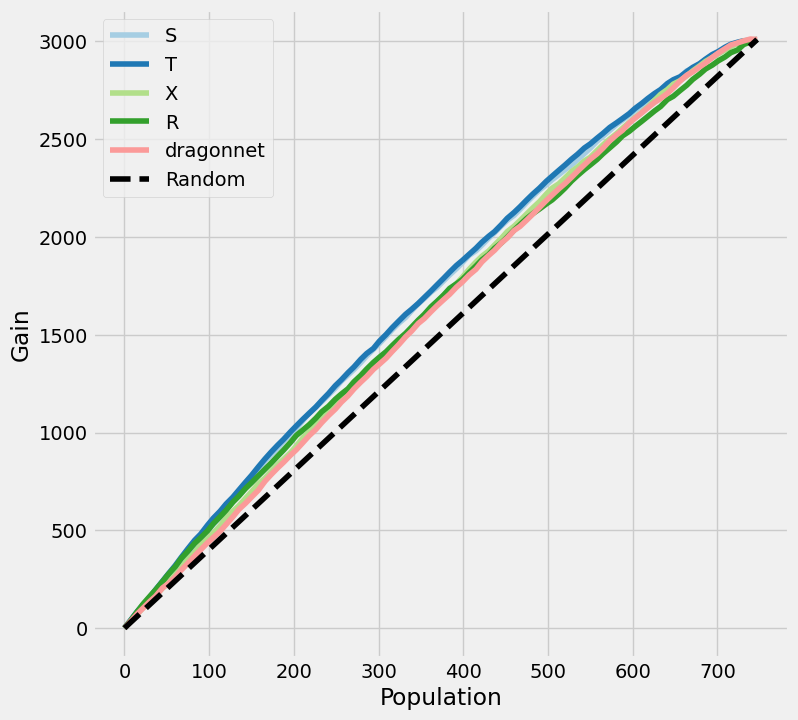

In [35]:
plot_gain(df_preds)

DragonNet 논문에 따르면 아래와 같은 상황에서 적용하기 더 좋다고 알려져 있습니다. 특히 논문에서는 성향점수 모델이 빠진 TARNET가 비교를 하고 있습니다:

- DragonNet은 처치 ($T$)에는 무관하고 결과값 ($Y$)에만 관련 있는 데이터를 제거하는 데에 효과적입니다.

- 성향 점수를 예측하는 Head는 단순한 Logisitic Regression을 권장합니다. 이를 통해 표현층($Z$)이 성향 점수 정보에 강하게 결합되도록 강제하게 됩니다.

- 모델 훈련과 최종 효과 추정에 Data Spliting 없이 사용하는 것을 권장합니다.